# Cell 1:Imports and Data Loading

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro
from sklearn.preprocessing import RobustScaler

# Load the dataset from the raw folder (relative to the notebooks folder)
df = pd.read_csv('../data/raw/full_leish_data_2010-2022.csv')

# Verify the shape to confirm all 156 rows are loaded
print(f"Initial Dataset Shape: {df.shape}")
df.head()

Initial Dataset Shape: (156, 20)


,Annee,Mois,RH2M,TMP_MIN,TMP_MAX,WS2M,WS10M,WD10M,WD2M,UVA,UVB,CLOUD_AMT,SOIL_M,SOIL_W,SOIL_RW,PRECT_TOTAL,SURFACE_P,SH2M,Cases,Date
0,2010,1,58.067647,-10.09,25.55,2.966471,4.247059,311.408235,311.491765,8.597647,0.148824,36.217647,0.527647,0.522941,0.534118,40.324706,83.640588,3.928235,71,2010-01-01
1,2010,2,67.925294,-5.69,26.46,3.704706,5.248235,274.142353,273.551765,9.837059,0.193529,54.170588,0.591765,0.614706,0.604706,83.442941,83.284706,5.432353,54,2010-02-01
2,2010,3,55.660000,-2.11,29.61,3.304118,4.689412,289.415294,288.811765,13.687647,0.314118,42.922941,0.602941,0.616471,0.621765,29.156471,83.697059,4.890000,48,2010-03-01
3,2010,4,49.796471,0.37,32.36,2.674118,3.782353,256.629412,250.105882,16.078824,0.385294,47.584706,0.518824,0.485294,0.527059,1.240588,83.464118,5.765882,20,2010-04-01
4,2010,5,41.630000,1.15,34.27,3.589412,4.928235,316.550000,313.687647,18.395882,0.453529,32.672353,0.462941,0.368824,0.466471,0.310000,83.564118,4.973529,17,2010-05-01


# Cell 2:Distribution Analysis for PRECT_TOTAL

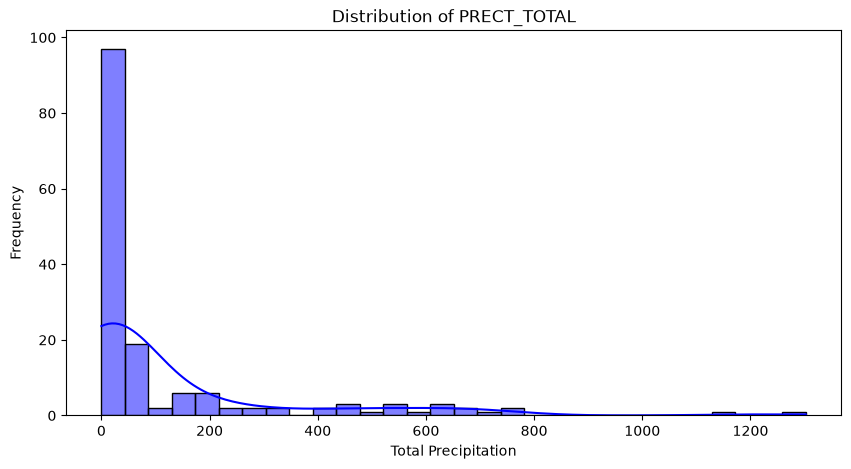

Shapiro-Wilk Test - Statistic: 0.5937, p-value: 0.0000
Conclusion: PRECT_TOTAL is NOT normally distributed (likely skewed).


In [18]:
# Visualize the distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['PRECT_TOTAL'], kde=True, bins=30, color='blue')
plt.title('Distribution of PRECT_TOTAL')
plt.xlabel('Total Precipitation')
plt.ylabel('Frequency')
plt.show()

# Shapiro-Wilk test for normality
stat, p_value = shapiro(df['PRECT_TOTAL'].dropna())
print(f"Shapiro-Wilk Test - Statistic: {stat:.4f}, p-value: {p_value:.4f}")

if p_value > 0.05:
    print("Conclusion: PRECT_TOTAL looks normally distributed.")
else:
    print("Conclusion: PRECT_TOTAL is NOT normally distributed (likely skewed).")

# Cell 3:Outlier Handling (Winsorization)

In [19]:
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Binarize the target and split the data FIRST
df['Cases_Class'] = pd.qcut(df['Cases'], q=2, labels=[0, 1])

continuous_cols = ['RH2M', 'TMP_MIN', 'TMP_MAX', 'WS2M', 'WS10M', 'WD10M', 
                   'WD2M', 'UVA', 'UVB', 'CLOUD_AMT', 'SOIL_M', 'SOIL_W', 
                   'SOIL_RW', 'PRECT_TOTAL', 'SURFACE_P', 'SH2M']

X = df.drop(columns=['Cases', 'Cases_Class', 'Mois', 'Date'], errors='ignore')
y = df['Cases_Class']

# 80:20 Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# 2. Calculate clipping bounds ONLY on the training data
def get_clipping_bounds(series, lower_percentile=0.05, upper_percentile=0.95):
    return series.quantile(lower_percentile), series.quantile(upper_percentile)

# 3. Apply these bounds to both train and test data
for col in continuous_cols:
    if col in X_train.columns:
        lower, upper = get_clipping_bounds(X_train[col])
        X_train[col] = X_train[col].clip(lower=lower, upper=upper)
        X_test[col] = X_test[col].clip(lower=lower, upper=upper)

print(f"Data split and outliers clipped.")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

Data split and outliers clipped.
X_train shape: (124, 17), X_test shape: (32, 17)


# Cell 4:Correlation Study & Parameter Reduction

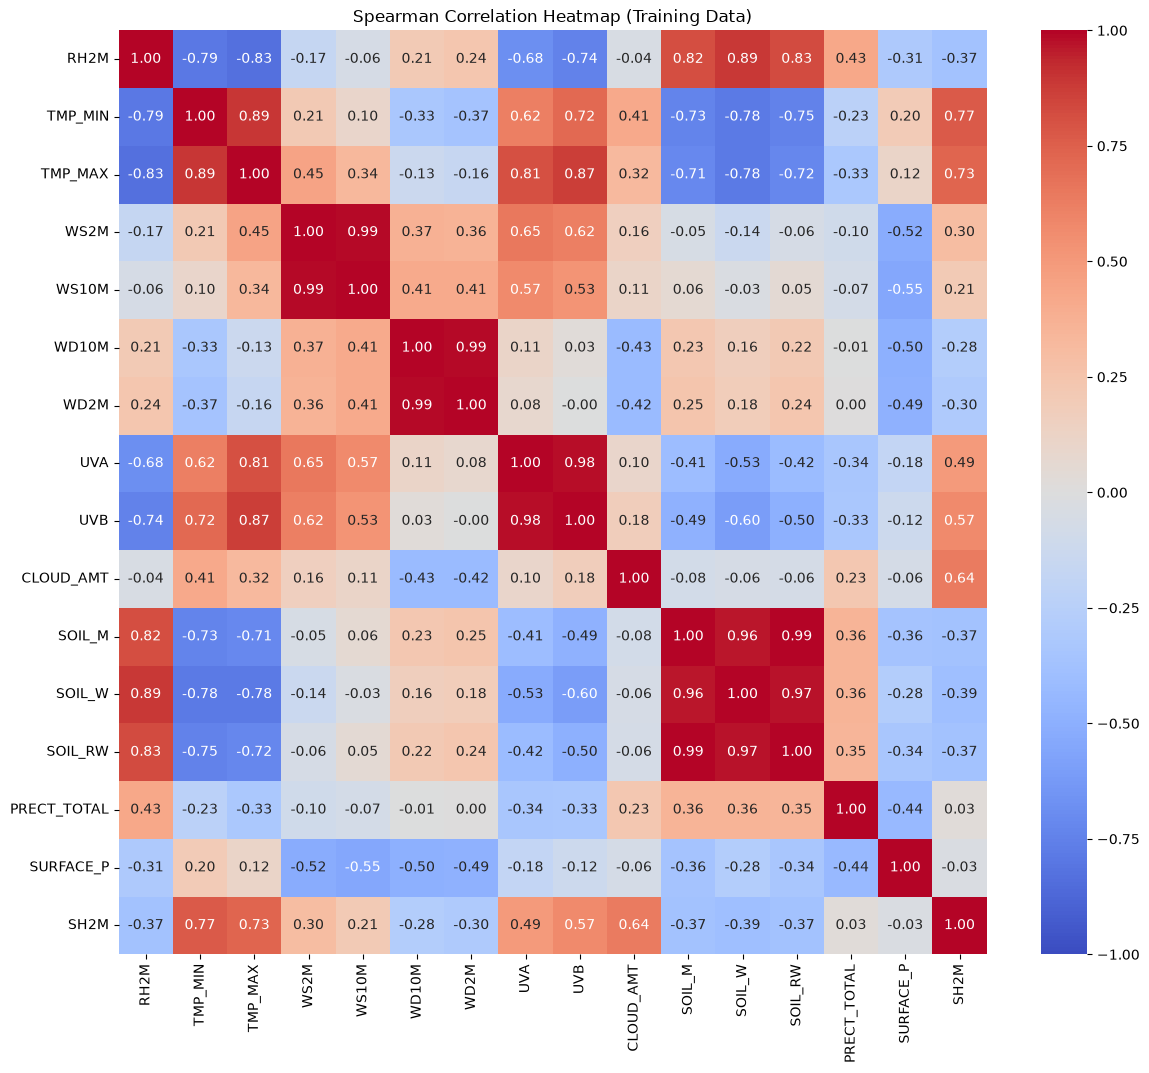

Highly correlated pairs found in training data:
- TMP_MAX & TMP_MIN: 0.89
- WS10M & WS2M: 0.99
- WD2M & WD10M: 0.99
- UVB & TMP_MAX: 0.87
- UVB & UVA: 0.98
- SOIL_W & RH2M: 0.89
- SOIL_W & SOIL_M: 0.96
- SOIL_RW & SOIL_M: 0.99
- SOIL_RW & SOIL_W: 0.97

Columns dynamically dropped: ['SOIL_W', 'RH2M', 'SOIL_M', 'WD10M', 'TMP_MIN', 'TMP_MAX', 'UVA', 'WS2M']
X_train shape after dropping: (124, 9)


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate correlation matrix ONLY on training data
corr_matrix = X_train[continuous_cols].corr(method='spearman')

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Spearman Correlation Heatmap (Training Data)')
plt.show()

# 2. Automatically identify and drop highly correlated pairs dynamically
high_corr_pairs = []
cols_to_drop = set() # Using a set prevents duplicate column names

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            colname_i = corr_matrix.columns[i]
            colname_j = corr_matrix.columns[j]
            high_corr_pairs.append((colname_i, colname_j, corr_matrix.iloc[i, j]))
            # Automatically flag one of the two variables to be dropped
            cols_to_drop.add(colname_j) 

print("Highly correlated pairs found in training data:")
for pair in high_corr_pairs:
    print(f"- {pair[0]} & {pair[1]}: {pair[2]:.2f}")

cols_to_drop = list(cols_to_drop)

# 3. Drop them from both Train and Test sets
X_train = X_train.drop(columns=cols_to_drop, errors='ignore')
X_test = X_test.drop(columns=cols_to_drop, errors='ignore')

# Update the continuous columns list
continuous_cols_kept = [col for col in continuous_cols if col not in cols_to_drop]

print(f"\nColumns dynamically dropped: {cols_to_drop}")
print(f"X_train shape after dropping: {X_train.shape}") 

# Cell 5: Scaling and PCA Variance Visualization

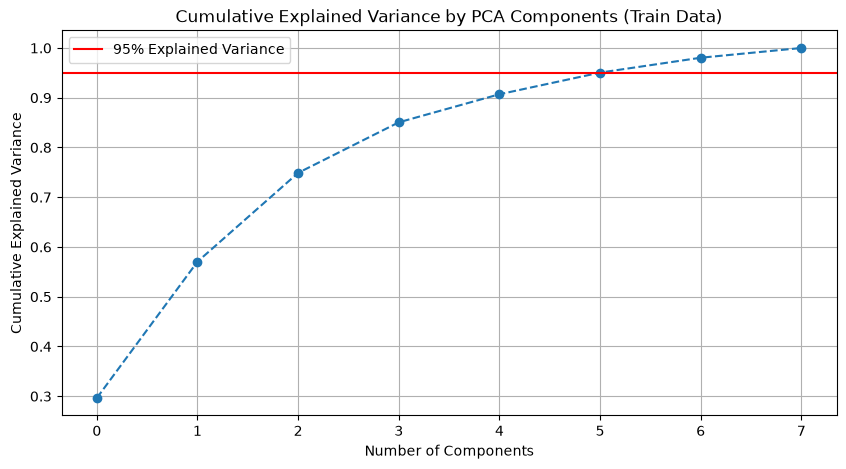

In [21]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Scale based ONLY on X_train to prevent leakage
scaler_viz = StandardScaler()
scaled_train_features = scaler_viz.fit_transform(X_train[continuous_cols_kept])

# 2. Fit PCA on the training data to visualize variance
pca_viz = PCA()
pca_viz.fit(scaled_train_features)

# 3. Plot Explained Variance
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca_viz.explained_variance_ratio_), marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components (Train Data)')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# Cellule 6 : Entraînement XGBoost et Diagnostics

In [24]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score
from sklearn.dummy import DummyClassifier
import joblib

# 1. Define Target and Features FIRST
df['Cases_Class'] = pd.qcut(df['Cases'], q=2, labels=[0, 1])
X = df.drop(columns=['Cases', 'Cases_Class', 'Mois', 'Date'] + cols_to_drop, errors='ignore')
y = df['Cases_Class']

# 2. Split the data before ANY transformations
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# 3. Calculate Baseline Error (Avoidable Bias reference)
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
baseline_acc = dummy_clf.score(X_train, y_train)
baseline_error = 1 - baseline_acc

# 4. Build the Leak-Free Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('xgb', xgb.XGBClassifier(
        max_depth=2,
        learning_rate=0.01,
        n_estimators=100,
        subsample=0.7,
        colsample_bytree=0.7,
        gamma=2.0,
        reg_lambda=15.0,
        eval_metric='logloss',
        random_state=42
    ))
])

# 5. Cross-Validation (The Pipeline prevents leakage inside the folds)
cv_results = cross_validate(
    pipeline, 
    X_train, 
    y_train, 
    cv=5, 
    scoring=['accuracy', 'precision'], 
    return_train_score=True
)

# Extract Mean Metrics from CV
train_accuracy = np.mean(cv_results['train_accuracy'])
cv_accuracy = np.mean(cv_results['test_accuracy'])
train_precision = np.mean(cv_results['train_precision'])
cv_precision = np.mean(cv_results['test_precision'])

# 6. Final Evaluation on Holdout Set
pipeline.fit(X_train, y_train)
test_predictions = pipeline.predict(X_test)
test_accuracy = accuracy_score(y_test, test_predictions)
test_precision = precision_score(y_test, test_predictions, zero_division=0)

# 7. Bias / Variance Calculations
train_error = 1 - train_accuracy
cv_error = 1 - cv_accuracy

bias = train_error
avoidable_bias = max(0, train_error - baseline_error)
variance = max(0, cv_error - train_error)

# ==========================================
# PRINT RESULTS & DIAGNOSTICS
# ==========================================

print("--- CLASSIFICATION METRICS ---")
print(f"Accuracy (Train) : {train_accuracy * 100:.2f}%")
print(f"Accuracy (CV)    : {cv_accuracy * 100:.2f}%")
print(f"Accuracy (Test)  : {test_accuracy * 100:.2f}%\n")

print(f"Precision (Train): {train_precision * 100:.2f}%")
print(f"Precision (CV)   : {cv_precision * 100:.2f}%")
print(f"Precision (Test) : {test_precision * 100:.2f}%\n")

print("--- DIAGNOSTICS BIAIS / VARIANCE ---")
print(f"Erreur de Base (Baseline) : {baseline_error:.4f} (Prédiction de la classe majoritaire)")
print(f"Biais Total               : {bias:.4f}")
print(f"Biais Évitable            : {avoidable_bias:.4f}")
print(f"Variance                  : {variance:.4f}\n")

if avoidable_bias > variance:
    print("Diagnostic : SOUS-APPRENTISSAGE (Underfitting).")
elif variance > avoidable_bias:
    print("Diagnostic : SUR-APPRENTISSAGE (Overfitting).")
else:
    print("Diagnostic : Équilibre stable atteint.")

# ==========================================
# HOW TO DOWNLOAD / SAVE YOUR RESULTS
# ==========================================

# Save the actual predictions alongside the test data to a CSV file
results_df = X_test.copy()
results_df['Actual_Class'] = y_test
results_df['Predicted_Class'] = test_predictions
results_df.to_csv('xgboost_test_predictions.csv', index=False)
print("\nSaved predictions to 'xgboost_test_predictions.csv'")

# Save the entire trained pipeline (Scaler + PCA + XGBoost model)
joblib.dump(pipeline, 'leishmaniasis_pipeline.pkl')
print("Saved the trained pipeline to 'leishmaniasis_pipeline.pkl'")

--- CLASSIFICATION METRICS ---
Accuracy (Train) : 83.27%
Accuracy (CV)    : 78.27%
Accuracy (Test)  : 78.12%

Precision (Train): 86.70%
Precision (CV)   : 86.05%
Precision (Test) : 76.47%

--- DIAGNOSTICS BIAIS / VARIANCE ---
Erreur de Base (Baseline) : 0.4839 (Prédiction de la classe majoritaire)
Biais Total               : 0.1673
Biais Évitable            : 0.0000
Variance                  : 0.0500

Diagnostic : SUR-APPRENTISSAGE (Overfitting).

Saved predictions to 'xgboost_test_predictions.csv'
Saved the trained pipeline to 'leishmaniasis_pipeline.pkl'
